# GCCR Slack Geographic Diversity

Analysis of geographic participation patterns. Produces `outputs/f-slack-diversity.png`.

Participation Ratio = (messages from country X / total messages) / (total users from country X / all users)

Countries where message share exceeds user share score >1 (High Engagement). Countries where message share is below user share score <1 (Low or Moderate Engagement). Countries with no messages score 0 (No Activity).

## Setup

In [1]:
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")


In [2]:
# Install required packages
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "geopandas", "countrycode", "seaborn", "jenkspy"], check=True)


CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'geopandas', 'countrycode', 'seaborn', 'jenkspy'], returncode=0)

In [3]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")
from countrycode import countrycode

# Mako palette matching R viridis option G: begin=0.3, end=0.9, direction=-1, alpha=0.9
_mako_full = sns.color_palette("mako", as_cmap=True)
_n = 256
_colors = _mako_full(np.linspace(0.9, 0.3, _n))
_colors[:, 3] = 0.9
MAKO = LinearSegmentedColormap.from_list("mako_r_narrow", _colors, N=_n)

# Four category colors matching R palette
C_4 = ["#A8E1BC", "#3DB4AD", "#357BA2", "#414081"]


In [4]:
mapdf = pd.read_csv(os.path.join("data", "slack-diversity.csv"))

## Geographic Participation Map (Paper Figure)

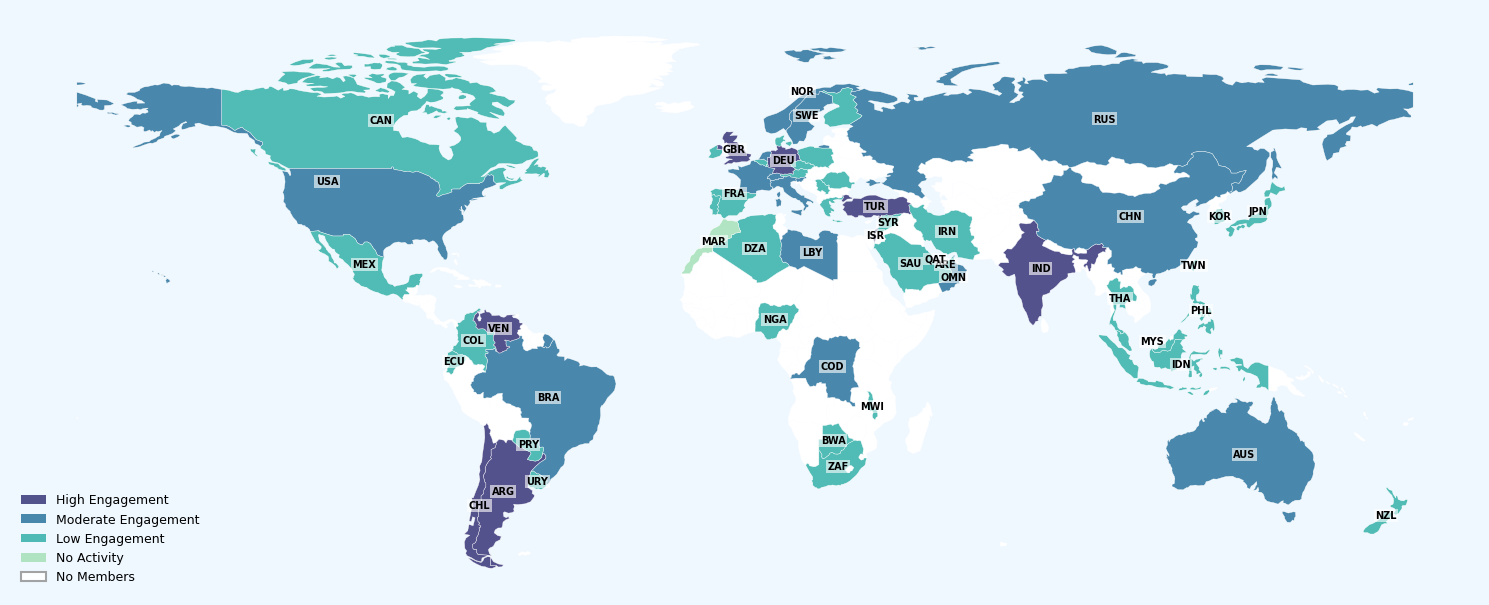

Saved: outputs/f-slack-diversity.png


In [5]:
# European countries — selective labeling rules apply
# RUS excluded (large landmass, label like non-Europe)
# FRA, SWE, NOR included in Moderate Engagement exceptions due to large landmass
EUROPE_ISO3 = {
    "ALB", "AND", "AUT", "BLR", "BEL", "BIH", "BGR", "HRV", "CYP", "CZE",
    "DNK", "EST", "FIN", "FRA", "DEU", "GRC", "HUN", "ISL", "IRL", "ITA",
    "XKX", "LVA", "LIE", "LTU", "LUX", "MLT", "MDA", "MCO", "MNE", "NLD",
    "MKD", "NOR", "POL", "PRT", "ROU", "SMR", "SRB", "SVK", "SVN",
    "ESP", "SWE", "CHE", "UKR", "GBR", "VAT", "TUR"
}

# Large European countries labeled even for Moderate Engagement
EUROPE_LARGE_LABEL = {"FRA", "SWE", "NOR"}

# Load world shapefile from Natural Earth
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)
world = world[world["NAME"] != "Antarctica"]
world = world.rename(columns={"NAME": "name"})
world["ISO3"] = countrycode(world["name"].tolist(), origin="country.name", destination="iso3c")

# Join participation ratio to world map
world_map = world.merge(mapdf[["ISO3", "Part_Ratio", "Category"]], on="ISO3", how="left")
world_map["Category"] = world_map["Category"].fillna("No Data")

# Map categories to numeric values: 1=lightest (No Activity), 4=darkest (High Engagement)
cat_order = {
    "No Activity":         1,
    "Low Engagement":      2,
    "Moderate Engagement": 3,
    "High Engagement":     4
}
world_map["cat_num"] = world_map["Category"].map(cat_order)

bounds = [0.5, 1.5, 2.5, 3.5, 4.5]
norm   = BoundaryNorm(bounds, MAKO.N)

# Build label set
# Outside Europe (incl. RUS): label all countries with any category except No Data
label_outside_europe = world_map[
    (~world_map["ISO3"].isin(EUROPE_ISO3)) &
    (world_map["Category"].isin(["No Activity", "Low Engagement", "Moderate Engagement", "High Engagement"]))
].copy()

# Inside Europe: label High Engagement, No Activity, and large landmass Moderate countries
label_europe = world_map[
    (world_map["ISO3"].isin(EUROPE_ISO3)) &
    (
        (world_map["Category"].isin(["High Engagement", "No Activity"])) |
        (world_map["ISO3"].isin(EUROPE_LARGE_LABEL))
    )
].copy()

to_label = pd.concat([label_outside_europe, label_europe]).drop_duplicates("ISO3")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world_map.plot(color="white", edgecolor="white", linewidth=0.3, ax=ax)
categorized = world_map[world_map["Category"] != "No Data"].copy()
categorized.plot(
    column="cat_num", cmap=MAKO, norm=norm,
    edgecolor="white", linewidth=0.3, ax=ax, alpha=0.9
)

# Ocean color
ax.set_facecolor("aliceblue")
fig.patch.set_facecolor("aliceblue")

# Labels with semi-transparent white mask (alpha=0.6 matches R map)
for _, row in to_label.iterrows():
    centroid = row.geometry.centroid
    x, y = centroid.x, centroid.y
    label = str(row["ISO3"])
    ax.text(
        x, y, label,
        fontsize=7, fontweight="bold", ha="center", va="center",
        bbox=dict(boxstyle="square,pad=0.15", facecolor="white", alpha=0.6, edgecolor="none")
    )

# Legend — reversed so High Engagement appears on top
legend_labels = ["High Engagement", "Moderate Engagement", "Low Engagement", "No Activity", "No Members"]
legend_patches = [
    mpatches.Patch(facecolor=c, label=l, alpha=0.9, edgecolor="#999999" if c == "white" else None, linewidth=1.5 if c == "white" else 0)
    for c, l in zip(list(reversed(C_4)) + ["white"], legend_labels)
]
ax.legend(handles=legend_patches, loc="lower left", frameon=False, fontsize=9)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join("outputs", "f-slack-diversity.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/f-slack-diversity.png")
